# StrokeGuard AI — Bonus Phase: SHAP Explainability

Goal: explain *why* the model makes each prediction, using SHAP — a well-established, math-backed method (not a guess or hardcoded rule).

**In plain terms:** SHAP tells you, for one specific patient, how much each feature (age, glucose, hypertension, etc.) pushed their risk score up or down compared to the average patient. It's the current standard for explainable ML.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

shap.initjs()


c:\dataScience+ML internship 2026\strokeGuard AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Everything from Previous Phases

Nothing to redo — we reuse the trained model, preprocessor, and processed data.

In [2]:
model = joblib.load('../models/best_stroke_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')
data = joblib.load('../data/processed/processed_data.pkl')

X_train = data['X_train']
X_test = data['X_test']
y_test = data['y_test']
feature_names = data['feature_names']

# SHAP works best with dense arrays (our data may be a sparse matrix from OneHotEncoder)
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else np.array(X_train)
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else np.array(X_test)

print('Model type:', type(model).__name__)
print('Train shape:', X_train_dense.shape)
print('Test shape:', X_test_dense.shape)


Model type: LogisticRegression
Train shape: (7776, 22)
Test shape: (1022, 22)


## 2. Create the SHAP Explainer

Since our model is Logistic Regression (a linear model), we use `LinearExplainer` — it's fast and exact for linear models, no approximation needed. We give it a background sample (a reference point representing a 'typical' patient) so it can measure each feature's effect relative to that baseline.

In [3]:
# A smaller background sample keeps things fast without losing accuracy
background = shap.sample(X_train_dense, 100, random_state=42)

explainer = shap.LinearExplainer(model, background)
shap_values = explainer(X_test_dense)

print('SHAP values computed for', shap_values.shape[0], 'test patients')


SHAP values computed for 1022 test patients


## 3. Global Feature Importance — Summary Plot

This shows, across ALL test patients, which features matter most overall, and whether high or low values of that feature tend to push risk up or down.

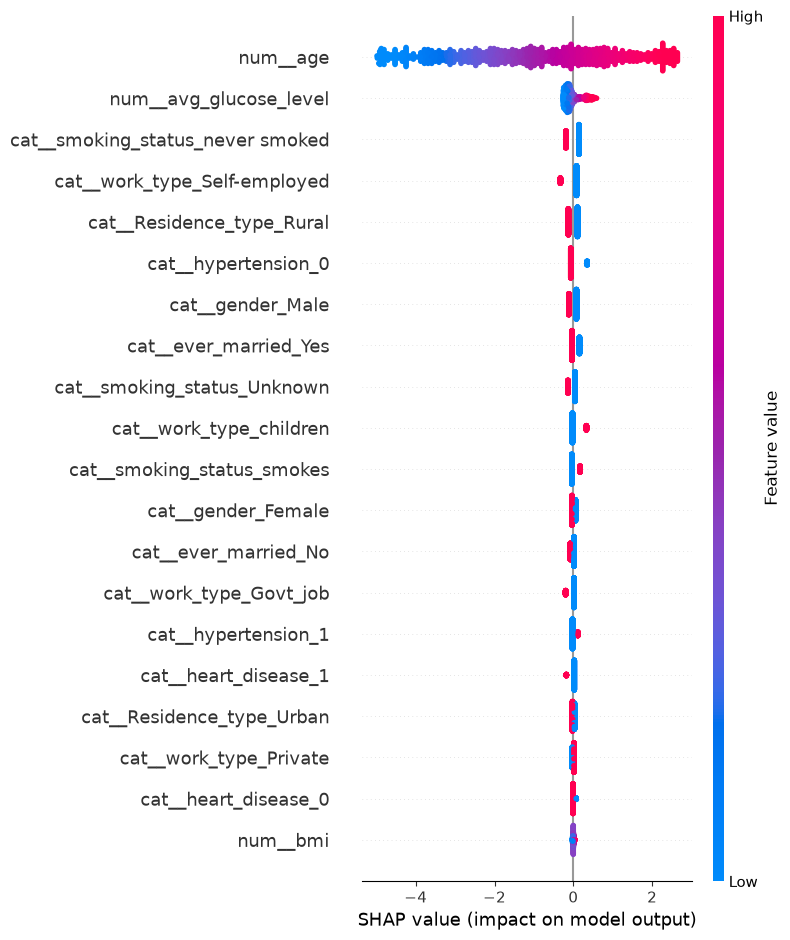

In [5]:
plt.figure()
shap.summary_plot(shap_values.values, X_test_dense, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../images/shap_summary_plot.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Which 2-3 features have the biggest overall impact? Does this match what you found in your EDA?)_

> 

## 4. Explain One Individual Prediction — Waterfall Plot

Let's pick one real patient from the test set who actually had a stroke, and see exactly how the model arrived at its prediction for them specifically.

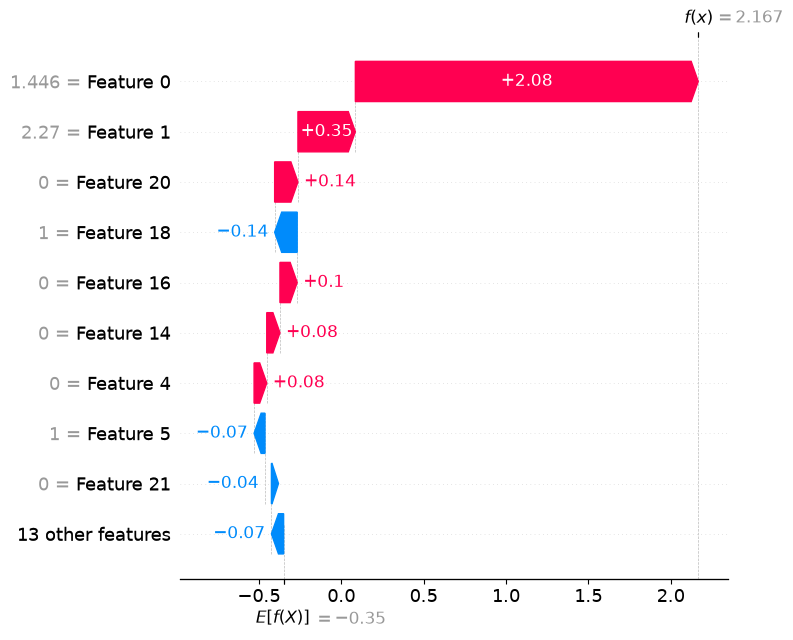

In [6]:
# Find a test patient who actually had a stroke
stroke_indices = np.where(y_test.values == 1)[0]
example_index = stroke_indices[0]

plt.figure()
shap.plots.waterfall(shap_values[example_index], show=False)
plt.tight_layout()
plt.savefig('../images/shap_waterfall_example.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(For this specific patient, what pushed their risk up the most?)_

> 

## 5. Save the Background Sample for the App

The app will recreate this same explainer on the fly for any new patient someone enters — this background sample is all it needs to do that quickly.

In [7]:
joblib.dump(background, '../models/shap_background.pkl')
print('Saved shap_background.pkl')


Saved shap_background.pkl


## Summary

Write 2-3 sentences on what SHAP added to your project and why it matters for a healthcare model specifically.

- 
- 